# Baseline
Ansatz:
- Übersicht der Multi-view Pig Posture Recognition Challenge
- Datenanalyse und -vorverarbeitung
- Baseline Modellierung für zukunfitge Optimierungen

In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import json
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

<jemalloc>: Unsupported system page size


Using device: cuda:3


## Datenanalyse

In [2]:
data_dir = "/datasets/multi-view-pig-posture-recognition/"
train1_df = pd.read_csv(os.path.join(data_dir, "train1.csv"))
train2_df = pd.read_csv(os.path.join(data_dir, "train2.csv"))
dir_train1 = os.path.join(data_dir, "train1_images")
dir_train2 = os.path.join(data_dir, "train2_images")

test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
dir_test = os.path.join(data_dir, "test_images")

In [3]:
# Datenüberblick der trainings spalten
train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [4]:
# Datenüberblick der Test spalten
test_df.head()

,row_id,image_id,width,height,bbox
0,test_pen1_tur_cam1_20250920_174649_0000,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[432.0,291.0,306.0,394.0]"
1,test_pen1_tur_cam1_20250920_174649_0001,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[237.0,254.0,246.0,402.0]"
2,test_pen1_tur_cam1_20250920_174649_0002,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[742.5,387.0,235.0,258.0]"
3,test_pen1_tur_cam1_20250920_174649_0003,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[357.5,263.0,234.0,374.0]"
4,test_pen1_tur_cam1_20250920_174649_0004,pen1_tur_cam1_20250920_174649.jpg,1280,720,"[342.5,2.0,356.0,157.0]"


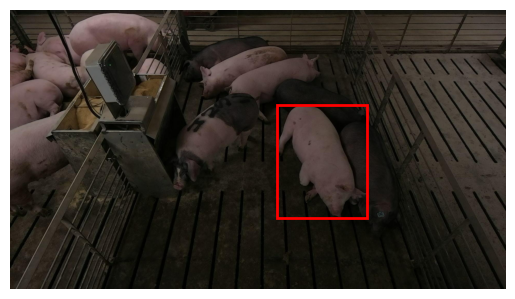

In [5]:
def parse_bbox(bbox_str):
    if isinstance(bbox_str, str):
        return [float(x) for x in bbox_str.replace("[", "").replace("]", "").split(",")]
    return bbox_str


def parse_bbox_safe(x):
    if isinstance(x, str):
        return [float(i) for i in x.replace("[", "").replace("]", "").split(",")]
    return x


def show_image_with_bbox(image_path, bbox):
    image = Image.open(image_path)
    plt.imshow(image)
    x, y, width, height = bbox
    plt.gca().add_patch(
        plt.Rectangle(
            (x, y), width, height, edgecolor="red", facecolor="none", linewidth=2
        )
    )
    plt.axis("off")
    plt.show()


row = train1_df.iloc[0]
bbox_data = parse_bbox(row["bbox"])
img_path = os.path.join(dir_train1, row["image_id"])
show_image_with_bbox(img_path, bbox_data)

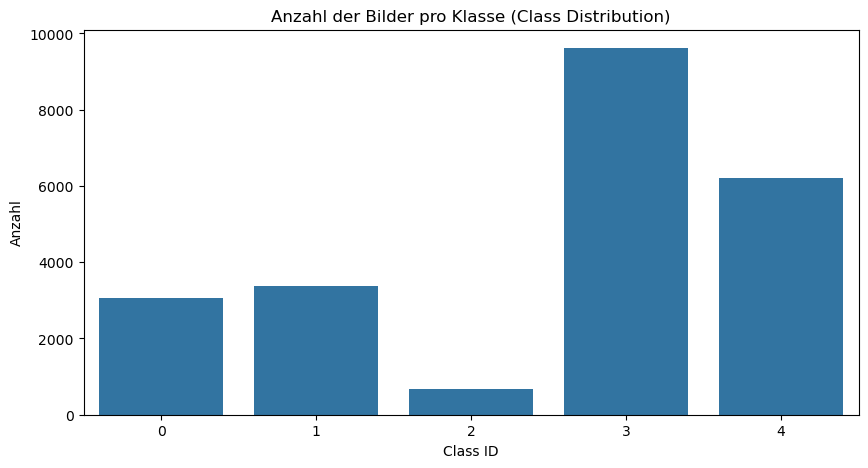

In [6]:
class_counts = train1_df["class_id"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Anzahl der Bilder pro Klasse (Class Distribution)")
plt.xlabel("Class ID")
plt.ylabel("Anzahl")
plt.show()

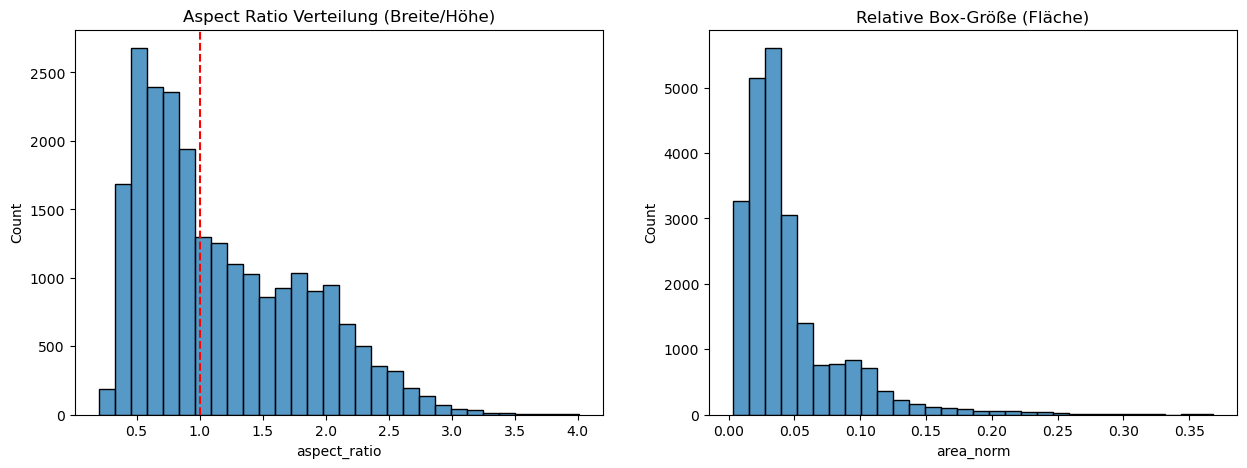

In [7]:
train1_df["bbox"] = train1_df["bbox"].apply(parse_bbox_safe)

bbox_data = train1_df["bbox"].tolist()
bbox_stats = pd.DataFrame(bbox_data, columns=["x", "y", "w", "h"])

bbox_stats["aspect_ratio"] = bbox_stats["w"] / bbox_stats["h"]
bbox_stats["area_norm"] = (bbox_stats["w"] * bbox_stats["h"]) / (1920 * 1080)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(bbox_stats["aspect_ratio"], bins=30, ax=ax[0])
ax[0].set_title("Aspect Ratio Verteilung (Breite/Höhe)")
ax[0].axvline(1, color="red", linestyle="--")

sns.histplot(bbox_stats["area_norm"], bins=30, ax=ax[1])
ax[1].set_title("Relative Box-Größe (Fläche)")
plt.show()

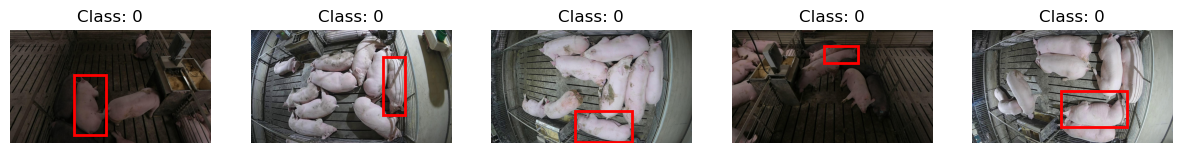

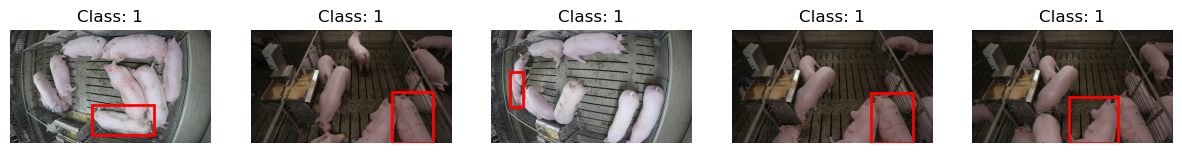

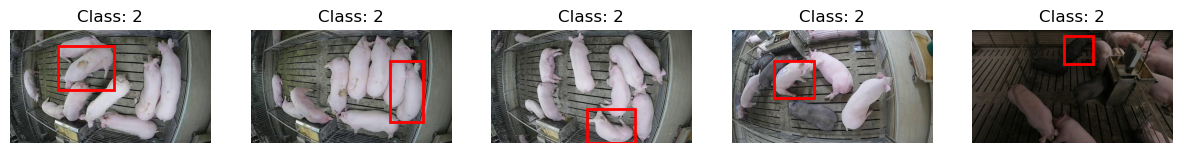

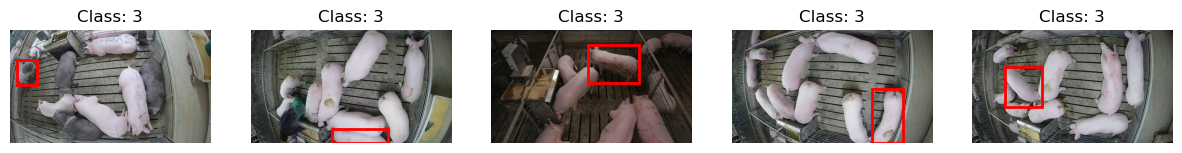

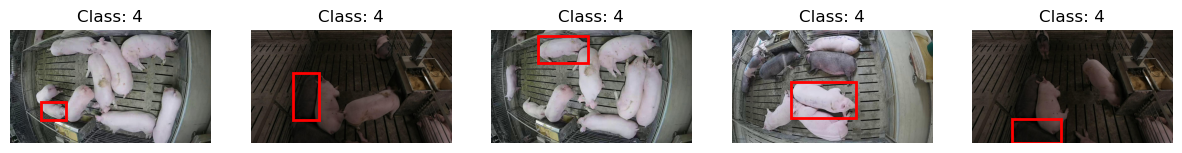

In [8]:
def show_grid_per_class(class_id, num_images=5):
    subset = train1_df[train1_df["class_id"] == class_id].sample(
        n=num_images, replace=True
    )
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = os.path.join(dir_train1, row["image_id"])
        bbox = row["bbox"]

        plt.subplot(1, num_images, i + 1)
        image = Image.open(img_path)
        plt.imshow(image)

        x, y, w, h = bbox
        plt.gca().add_patch(
            plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        )
        plt.axis("off")
        plt.title(f"Class: {class_id}")
    plt.show()


for c in range(5):
    show_grid_per_class(c)

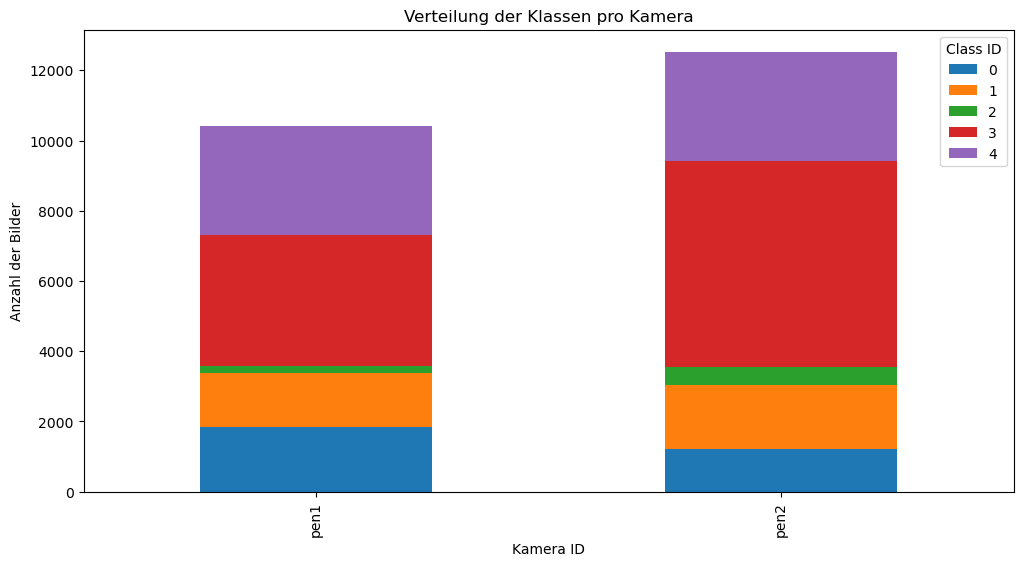

In [9]:
train1_df["camera_id"] = train1_df["image_id"].apply(lambda x: x.split("_")[0])
camera_class_counts = (
    train1_df.groupby(["camera_id", "class_id"]).size().unstack(fill_value=0)
)
plt.figure(figsize=(12, 6))
camera_class_counts.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Verteilung der Klassen pro Kamera")
plt.xlabel("Kamera ID")
plt.ylabel("Anzahl der Bilder")
plt.legend(title="Class ID")
plt.show()

# Model


In [10]:
class PigPostureDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label = row["class_id"]

        # Crop zum Bounding Box Bereich (Schwein ausschneiden)
        bbox = row["bbox"]
        if isinstance(bbox, str):
            bbox = [float(x) for x in bbox.replace("[", "").replace("]", "").split(",")]
        x, y, w, h = bbox
        # Sicherstellen, dass die Koordinaten innerhalb des Bildes liegen
        img_w, img_h = image.size
        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(img_w, int(x + w))
        y2 = min(img_h, int(y + h))
        image = image.crop((x1, y1, x2, y2))

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [12]:
train_split_df, val_split_df = train_test_split(
    train1_df, test_size=0.2, random_state=42, stratify=train1_df["class_id"]
)

print(f"Train: {len(train_split_df)} samples")
print(f"Val:   {len(val_split_df)} samples")

train_dataset = PigPostureDataset(train_split_df, dir_train1, transform=transform_train)
val_dataset = PigPostureDataset(val_split_df, dir_train1, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Train: 18347 samples
Val:   4587 samples


In [13]:
class PigPostureModel(nn.Module):
    def __init__(self, num_classes=5):
        super(PigPostureModel, self).__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        # Freeze all backbone layers
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Replace classifier head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def unfreeze_last_layers(self, num_layers=2):
        """Unfreeze the last N ResNet layers (layer3, layer4, etc.) for fine-tuning."""
        layers = [
            self.backbone.layer1,
            self.backbone.layer2,
            self.backbone.layer3,
            self.backbone.layer4,
        ]
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True
        print(f"Unfroze last {num_layers} backbone layers for fine-tuning.")

    def forward(self, x):
        return self.backbone(x)

In [14]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=10):
    model.to(device)
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []

    best_val_acc = 0.0

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        if scheduler:
            scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc:.4f}")

        # Save best model
        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print(f"  -> Neues bestes Modell gespeichert! (Val Acc: {best_val_acc:.4f})")

    # --- Plots ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, num_epochs + 1), train_loss_history, marker="o", label="Train Loss")
    axes[0].plot(range(1, num_epochs + 1), val_loss_history, marker="s", label="Val Loss")
    axes[0].set_title("Loss über Epochen")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(range(1, num_epochs + 1), val_acc_history, marker="o", color="green")
    axes[1].set_title("Validation Accuracy über Epochen")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid()

    plt.tight_layout()
    plt.show()

    print(f"\nBeste Validation Accuracy: {best_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


  0%|          | 0.00/97.8M [00:00<?, ?B/s]

=== Phase 1: Training Classifier Head ===


Epoch 1/10 [Val]: 100%|██████████| 144/144 [00:26<00:00,  5.51it/s]


Epoch 1/10 | Train Loss: 0.8945 | Val Loss: 0.7033 | Val Acc: 0.7340
  -> Neues bestes Modell gespeichert! (Val Acc: 0.7340)


...

Epoch 8/10 | Train Loss: 0.5547 | Val Loss: 0.5152 | Val Acc: 0.8049
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8049)


Epoch 9/10 [Val]: 100%|██████████| 144/144 [00:27<00:00,  5.23it/s]


Epoch 9/10 | Train Loss: 0.5384 | Val Loss: 0.4926 | Val Acc: 0.8228
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8228)


Epoch 10/10 [Val]: 100%|██████████| 144/144 [00:24<00:00,  5.83it/s]


Epoch 10/10 | Train Loss: 0.5365 | Val Loss: 0.4752 | Val Acc: 0.8260
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8260)


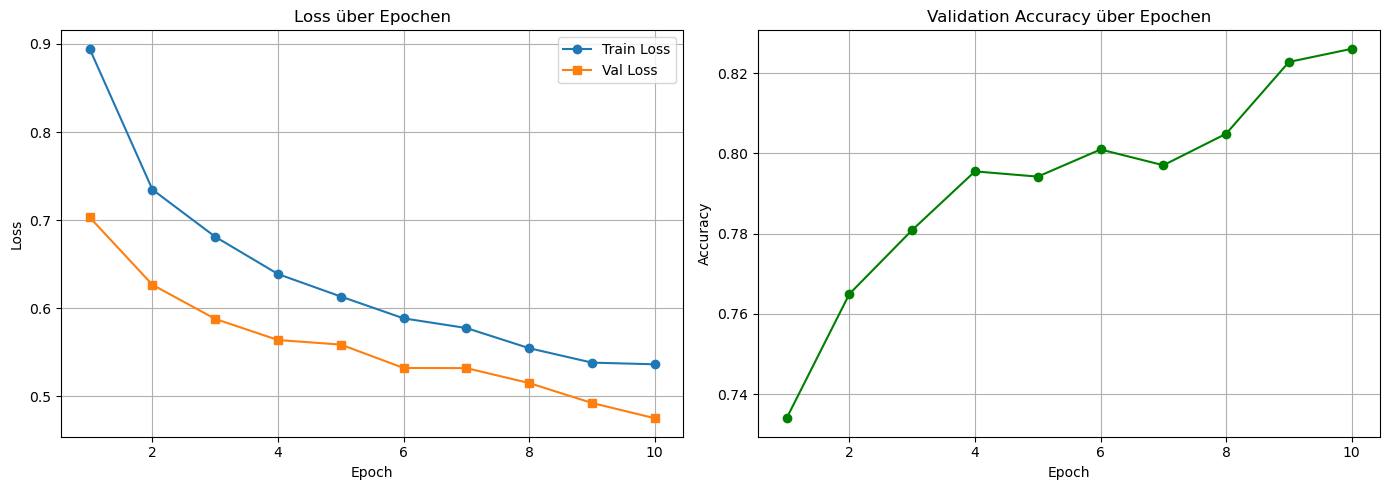


Beste Validation Accuracy: 0.8260


In [15]:
model = PigPostureModel(num_classes=5)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.backbone.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

print("=== Phase 1: Training Classifier Head ===")
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10)

Unfroze last 2 backbone layers for fine-tuning.
=== Phase 2: Fine-Tuning Last Backbone Layers ===


Epoch 1/10 [Val]: 100%|██████████| 144/144 [00:24<00:00,  5.79it/s]


Epoch 1/10 | Train Loss: 0.4637 | Val Loss: 0.4071 | Val Acc: 0.8476
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8476)


Epoch 2/10 [Val]: 100%|██████████| 144/144 [00:24<00:00,  5.80it/s]


Epoch 2/10 | Train Loss: 0.4028 | Val Loss: 0.3745 | Val Acc: 0.8600
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8600)


...

Epoch 8/10 | Train Loss: 0.2560 | Val Loss: 0.2733 | Val Acc: 0.9084
  -> Neues bestes Modell gespeichert! (Val Acc: 0.9084)


Epoch 9/10 [Val]: 100%|██████████| 144/144 [00:24<00:00,  5.78it/s]


Epoch 9/10 | Train Loss: 0.2467 | Val Loss: 0.2763 | Val Acc: 0.9036


Epoch 10/10 [Val]: 100%|██████████| 144/144 [00:25<00:00,  5.61it/s]


Epoch 10/10 | Train Loss: 0.2325 | Val Loss: 0.2628 | Val Acc: 0.9102
  -> Neues bestes Modell gespeichert! (Val Acc: 0.9102)


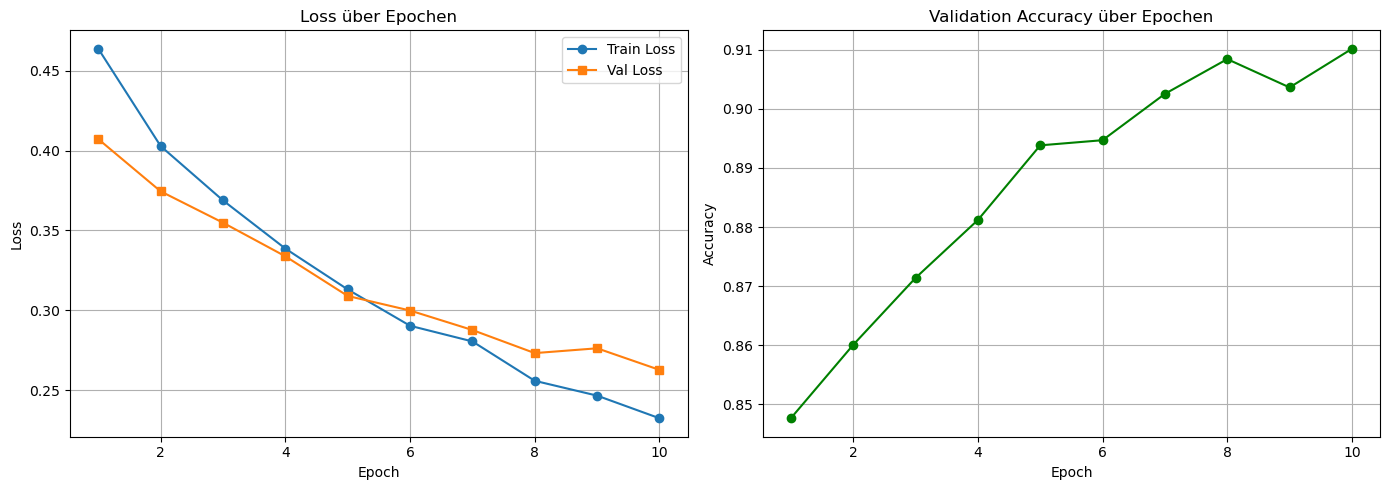


Beste Validation Accuracy: 0.9102


In [16]:
model.unfreeze_last_layers(num_layers=2)

optimizer_ft = torch.optim.Adam([
    {"params": model.backbone.layer3.parameters(), "lr": 1e-5},
    {"params": model.backbone.layer4.parameters(), "lr": 1e-5},
    {"params": model.backbone.fc.parameters(), "lr": 1e-4},
])
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode="min", patience=3, factor=0.5)

print("=== Phase 2: Fine-Tuning Last Backbone Layers ===")
train_model(model, train_loader, val_loader, criterion, optimizer_ft, scheduler_ft, num_epochs=10)

=== Evaluation auf Validation Set ===


Evaluating: 100%|██████████| 144/144 [00:25<00:00,  5.63it/s]



Accuracy: 0.9102


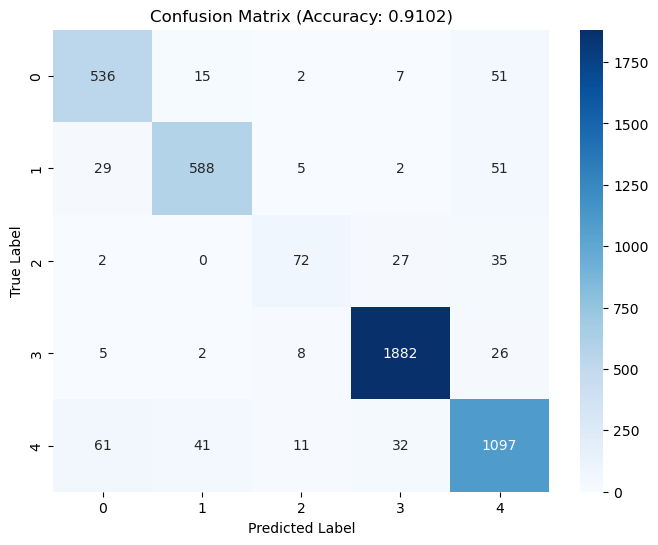

0.9101809461521692

In [17]:
# Cell 15: Bestes Modell laden und evaluieren
model.load_state_dict(torch.load("best_model.pth"))

def evaluate_model(model, dataloader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = correct / total
    print(f"\nAccuracy: {accuracy:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=range(5), yticklabels=range(5))
    plt.title(f"Confusion Matrix (Accuracy: {accuracy:.4f})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return accuracy


print("=== Evaluation auf Validation Set ===")
evaluate_model(model, val_loader)

In [21]:
# === Konfiguration ===
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
TEST_IMG_DIR = os.path.join(data_dir, "test_images")
BEST_MODEL_PATH = "best_model.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Gleiche Transforms wie bei Validation ===
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print(f"Anzahl Test-Samples: {len(test_df)}")
print(test_df.head())

# === Bestes Modell laden ===
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# === Inference ===
row_ids = []
predictions = []

with torch.no_grad():
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Inference"):
        row_id = row["row_id"]
        image_id = row["image_id"]
        
        # Bild über image_id laden
        img_path = os.path.join(TEST_IMG_DIR, image_id)
        image = Image.open(img_path).convert("RGB")
        
        # Bounding Box parsen und zuschneiden [x, y, w, h]
        bbox = json.loads(row["bbox"])
        x, y, w, h = bbox
        image = image.crop((x, y, x + w, y + h))
        
        # Transform anwenden
        image = val_transforms(image).unsqueeze(0).to(DEVICE)
        
        output = model(image)
        _, pred = torch.max(output, 1)
        
        row_ids.append(row_id)
        predictions.append(pred.item())

# === Submission erstellen & speichern ===
submission = pd.DataFrame({
    "row_id": row_ids,
    "class_id": predictions
})

submission.to_csv("T2_resnet_finetune.csv", index=False)

print("\n✅ Gespeichert als: T1_resnet_finetune.csv")
print(f"\nKlassenverteilung:")
print(submission["class_id"].value_counts().sort_index().to_string())
print(f"\nVorschau:")
print(submission.head())

Anzahl Test-Samples: 11708
                                    row_id                           image_id  \
0  test_pen1_tur_cam1_20250920_174649_0000  pen1_tur_cam1_20250920_174649.jpg   
1  test_pen1_tur_cam1_20250920_174649_0001  pen1_tur_cam1_20250920_174649.jpg   
2  test_pen1_tur_cam1_20250920_174649_0002  pen1_tur_cam1_20250920_174649.jpg   
3  test_pen1_tur_cam1_20250920_174649_0003  pen1_tur_cam1_20250920_174649.jpg   
4  test_pen1_tur_cam1_20250920_174649_0004  pen1_tur_cam1_20250920_174649.jpg   

   width  height                       bbox  
0   1280     720  [432.0,291.0,306.0,394.0]  
1   1280     720  [237.0,254.0,246.0,402.0]  
2   1280     720  [742.5,387.0,235.0,258.0]  
3   1280     720  [357.5,263.0,234.0,374.0]  
4   1280     720    [342.5,2.0,356.0,157.0]  


Inference: 100%|██████████| 11708/11708 [05:46<00:00, 33.81it/s]


✅ Gespeichert als: T2_resnet_finetune.csv

Klassenverteilung:
class_id
0    1488
1     332
2     720
3    5204
4    3964

Vorschau:
                                    row_id  class_id
0  test_pen1_tur_cam1_20250920_174649_0000         3
1  test_pen1_tur_cam1_20250920_174649_0001         1
2  test_pen1_tur_cam1_20250920_174649_0002         0
3  test_pen1_tur_cam1_20250920_174649_0003         3
4  test_pen1_tur_cam1_20250920_174649_0004         1


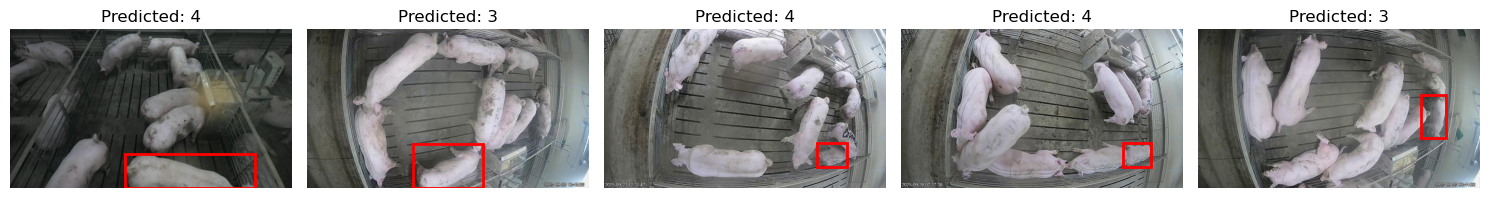

In [23]:
import matplotlib.pyplot as plt

# Submission mit test_df mergen, um image_id und bbox zu bekommen
submission_full = submission.merge(test_df[["row_id", "image_id", "bbox"]], on="row_id")

def show_predicted_images(df, img_dir, bbox_col="bbox", num_images=5):
    samples = df.sample(n=num_images).reset_index(drop=True)
    plt.figure(figsize=(15, 3))
    for i, row in samples.iterrows():
        img_path = os.path.join(img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        bbox = json.loads(row[bbox_col])
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        
        x, y, w, h = bbox
        plt.gca().add_patch(
            plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        )
        plt.title(f"Predicted: {row['class_id']}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predicted_images(submission_full, TEST_IMG_DIR, bbox_col="bbox", num_images=5)